<a href="https://colab.research.google.com/github/nafilafiryal/data_mining/blob/main/6_Tugas3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving atlanta_9-24-2016_9-30-2017.csv to atlanta_9-24-2016_9-30-2017.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv('atlanta_9-24-2016_9-30-2017.csv',
                  encoding='utf-8-sig')
df.head(10)

,Commodity Name,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,...,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode
0,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,140.0,154.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,145.0,154.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,150.0,154.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,150.0,150.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,10/01/2016,140.0,154.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
5,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,10/01/2016,145.0,154.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
6,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,10/01/2016,150.0,154.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
7,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,10/01/2016,150.0,150.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
8,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,10/08/2016,140.0,154.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
9,PUMPKINS,ATLANTA,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,10/08/2016,145.0,154.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Commodity Name   57 non-null     object 
 1   City Name        57 non-null     object 
 2   Type             0 non-null      float64
 3   Package          57 non-null     object 
 4   Variety          57 non-null     object 
 5   Sub Variety      1 non-null      object 
 6   Grade            0 non-null      float64
 7   Date             57 non-null     object 
 8   Low Price        57 non-null     float64
 9   High Price       57 non-null     float64
 10  Mostly Low       57 non-null     float64
 11  Mostly High      57 non-null     float64
 12  Origin           57 non-null     object 
 13  Origin District  0 non-null      float64
 14  Item Size        56 non-null     object 
 15  Color            0 non-null      float64
 16  Environment      0 non-null      float64
 17  Unit of Sale     0

In [6]:
df.describe()

,Type,Grade,Low Price,High Price,Mostly Low,Mostly High,Origin District,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Trans Mode
count,0.0,0.0,57.000000,57.000000,57.000000,57.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,139.184211,153.416667,139.184211,153.394737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,45.400857,62.973835,45.400857,63.022033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,14.500000,15.000000,14.500000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,135.000000,135.000000,135.000000,135.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,145.000000,150.000000,145.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,150.000000,154.750000,150.000000,154.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,210.000000,286.000000,210.000000,286.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Cek missing values
df.isnull().sum()

,0
Commodity Name,0
City Name,0
Type,57
Package,0
Variety,0
Sub Variety,56
Grade,57
Date,0
Low Price,0
High Price,0


In [8]:
# Lihat kolom yang tersedia
print(df.columns.tolist())

['Commodity Name', 'City Name', 'Type', 'Package', 'Variety', 'Sub Variety', 'Grade', 'Date', 'Low Price', 'High Price', 'Mostly Low', 'Mostly High', 'Origin', 'Origin District', 'Item Size', 'Color', 'Environment', 'Unit of Sale', 'Quality', 'Condition', 'Appearance', 'Storage', 'Crop', 'Repack', 'Trans Mode']


In [21]:
# Hapus spasi di nama kolom
df.columns = df.columns.str.strip()

# Pilih kolom yang dibutuhkan
df_clean = df[['Date', 'Low Price', 'High Price']].copy()

# Hapus baris yang ada nilai kosong
df_clean.dropna(inplace=True)

# Konversi tipe data harga ke numerik
df_clean['Low Price'] = pd.to_numeric(df_clean['Low Price'], errors='coerce')
df_clean['High Price'] = pd.to_numeric(df_clean['High Price'], errors='coerce')
df_clean.dropna(inplace=True)

# Buat kolom harga rata-rata
df_clean['Average_Price'] = (df_clean['Low Price'] +
                              df_clean['High Price']) / 2

# Konversi Date ke datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Kelompokkan per minggu — ambil rata-rata harga setiap minggu
df_weekly = df_clean.groupby('Date')['Average_Price'].mean().reset_index()
df_weekly = df_weekly.sort_values('Date').reset_index(drop=True)

# Buat Week_Number dari 1, 2, 3, ...
df_weekly['Week_Number'] = range(1, len(df_weekly) + 1)

print("Jumlah minggu unik:", len(df_weekly))
print(df_weekly)

Jumlah minggu unik: 11
         Date  Average_Price  Week_Number
0  2016-09-24     163.770833            1
1  2016-10-01     163.770833            2
2  2016-10-08     163.770833            3
3  2016-10-15     160.732143            4
4  2016-10-22     160.732143            5
5  2016-10-29     160.732143            6
6  2016-11-05     141.765625            7
7  2016-11-12      72.000000            8
8  2016-11-19      72.000000            9
9  2016-11-26      72.000000           10
10 2017-09-30     112.437500           11


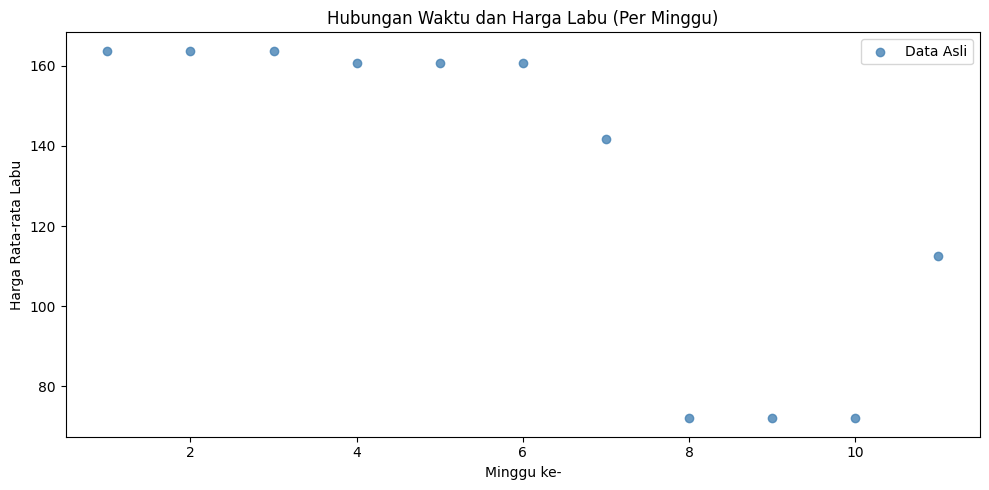

In [22]:
plt.figure(figsize=(10, 5))
plt.scatter(df_weekly['Week_Number'],
            df_weekly['Average_Price'],
            color='steelblue', alpha=0.8, label='Data Asli')
plt.xlabel("Minggu ke-")
plt.ylabel("Harga Rata-rata Labu")
plt.title("Hubungan Waktu dan Harga Labu (Per Minggu)")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
X = df_weekly[['Week_Number']]
y = df_weekly['Average_Price']

print("Jumlah data:", len(X))
print("Harga min:", y.min())
print("Harga max:", y.max())
print("Harga rata-rata:", y.mean())

Jumlah data: 11
Harga min: 72.0
Harga max: 163.77083333333334
Harga rata-rata: 131.24655032467533


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (8, 1)
Data testing : (3, 1)


In [25]:
hasil = {}

for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    hasil[degree] = {'model': model, 'poly': poly,
                     'rmse': rmse, 'r2': r2}

    print(f"Degree {degree} — RMSE: {rmse:.4f} | R²: {r2:.4f}")

Degree 2 — RMSE: 29.9221 | R²: 0.5058
Degree 3 — RMSE: 32.7290 | R²: 0.4087
Degree 4 — RMSE: 24.5785 | R²: 0.6665


In [26]:
print("=" * 45)
print(f"{'Degree':<10} {'RMSE':<15} {'R²':<15}")
print("=" * 45)
for degree in [2, 3, 4]:
    print(f"{degree:<10} {hasil[degree]['rmse']:<15.4f} {hasil[degree]['r2']:<15.4f}")
print("=" * 45)

# Temukan degree terbaik (R² tertinggi)
best_degree = max([2,3,4], key=lambda d: hasil[d]['r2'])
print(f"\nDegree terbaik: {best_degree}")
print(f"RMSE terbaik  : {hasil[best_degree]['rmse']:.4f}")
print(f"R² terbaik    : {hasil[best_degree]['r2']:.4f}")

Degree     RMSE            R²             
2          29.9221         0.5058         
3          32.7290         0.4087         
4          24.5785         0.6665         

Degree terbaik: 4
RMSE terbaik  : 24.5785
R² terbaik    : 0.6665


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


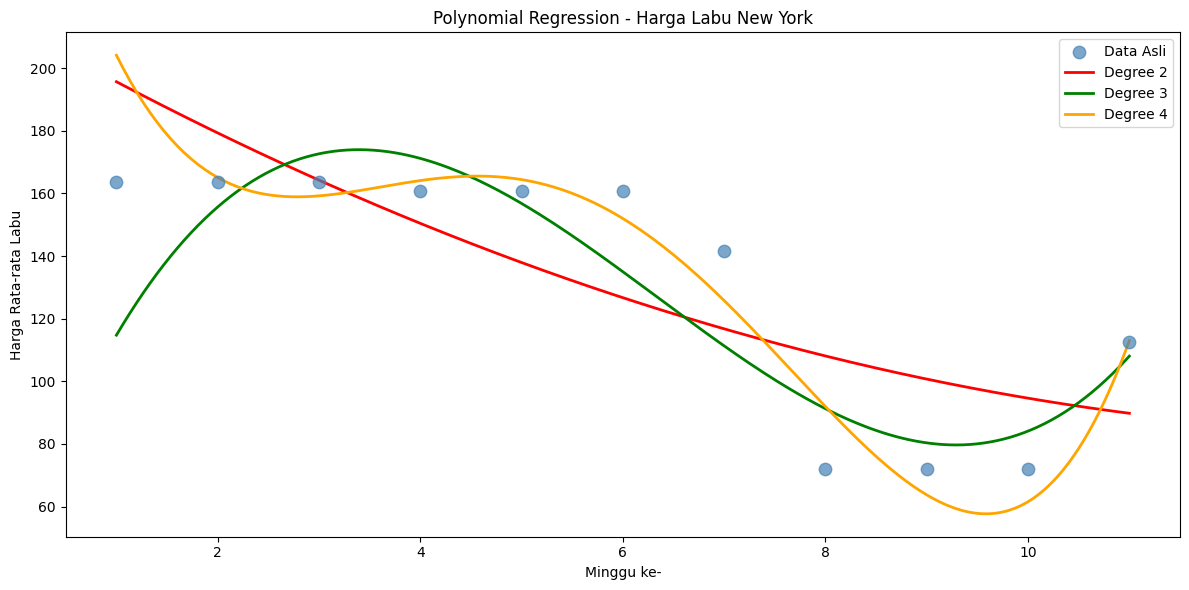

In [27]:
X_plot = np.linspace(X['Week_Number'].min(),
                      X['Week_Number'].max(),
                      300).reshape(-1, 1)

warna = {2: 'red', 3: 'green', 4: 'orange'}

plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='steelblue', alpha=0.7,
            label='Data Asli', zorder=5, s=80)

for degree in [2, 3, 4]:
    y_plot = hasil[degree]['model'].predict(
                hasil[degree]['poly'].transform(X_plot))
    plt.plot(X_plot, y_plot, color=warna[degree],
             linewidth=2, label=f'Degree {degree}')

plt.xlabel("Minggu ke-")
plt.ylabel("Harga Rata-rata Labu")
plt.title("Polynomial Regression - Harga Labu New York")
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


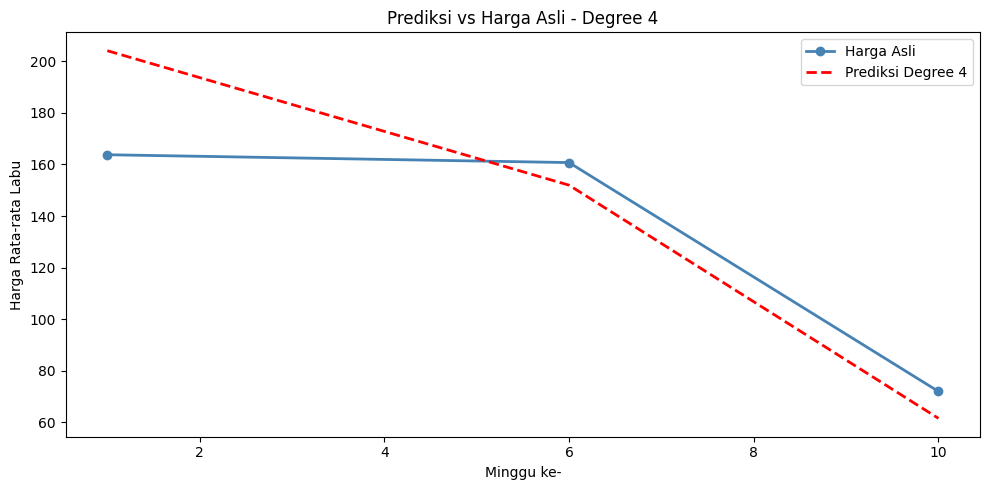

In [28]:
best_model = hasil[best_degree]['model']
best_poly = hasil[best_degree]['poly']

X_sorted = np.sort(X_test['Week_Number'].values).reshape(-1, 1)
y_sorted_pred = best_model.predict(best_poly.transform(X_sorted))
y_sorted_actual = y_test.values[
    np.argsort(X_test['Week_Number'].values)]

plt.figure(figsize=(10, 5))
plt.plot(X_sorted, y_sorted_actual,
         color='steelblue', linewidth=2,
         label='Harga Asli', marker='o', markersize=6)
plt.plot(X_sorted, y_sorted_pred,
         color='red', linewidth=2, linestyle='--',
         label=f'Prediksi Degree {best_degree}')
plt.xlabel("Minggu ke-")
plt.ylabel("Harga Rata-rata Labu")
plt.title(f"Prediksi vs Harga Asli - Degree {best_degree}")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
for minggu in [10, 20, 30]:
    minggu_arr = np.array([[minggu]])
    minggu_poly = best_poly.transform(minggu_arr)
    prediksi = best_model.predict(minggu_poly)
    print(f"Prediksi harga labu minggu ke-{minggu}: "
          f"{prediksi[0]:.2f}")

Prediksi harga labu minggu ke-10: 61.56
Prediksi harga labu minggu ke-20: 11071.27
Prediksi harga labu minggu ke-30: 100187.70


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
